In [1]:
# Required packages
import numpy as np
import pandas as pd

# Import KModes as chosen Clustering methods
!pip install kmodes
from kmodes.kmodes import KModes

# Data Visualization
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
df = pd.read_csv('/content/preprocessed_depression.csv')
df

,CGPA,CGPA (categorical),Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Work Study Hours,Financial Stress,Family History,Depression
0,5.03,Low,Moderate,High,Long,Healthy,Yes,Moderate,High,Yes,1
1,5.03,Low,High,High,Very short,Moderate,Yes,Low,Low,No,0
2,5.03,Low,Low,Moderate,Short,Moderate,No,Moderate,Moderate,No,0
3,5.03,Low,Low,High,Long,Healthy,No,Low,Moderate,No,0
4,5.03,Low,Low,High,Very short,Moderate,Yes,Low,Low,No,0
...,...,...,...,...,...,...,...,...,...,...,...
27857,10.00,High,High,High,Very short,Unhealthy,Yes,High,Low,Yes,1
27858,10.00,High,Moderate,Low,Long,Unhealthy,Yes,High,High,No,1
27859,10.00,High,High,Moderate,Very short,Moderate,Yes,High,Moderate,Yes,1
27860,10.00,High,Moderate,Low,Very short,Moderate,Yes,High,High,No,1


In [3]:
df.columns

Index(['CGPA', 'CGPA (categorical)', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts',
       'Work Study Hours', 'Financial Stress', 'Family History', 'Depression'],
      dtype='object')

In [4]:
# Check for null values
print(df.isnull().sum(), "\n")

# Check for unique values in categorical columns to identify potential invalid entries
for col in df.select_dtypes(include='object').columns:
    print(f"Unique values in '{col}'".ljust(40) + f": {df[col].unique()}")


CGPA                  0
CGPA (categorical)    0
Academic Pressure     0
Study Satisfaction    0
Sleep Duration        0
Dietary Habits        0
Suicidal Thoughts     0
Work Study Hours      0
Financial Stress      0
Family History        0
Depression            0
dtype: int64 

Unique values in 'CGPA (categorical)'   : ['Low' 'Average' 'High']
Unique values in 'Academic Pressure'    : ['Moderate' 'High' 'Low ']
Unique values in 'Study Satisfaction'   : ['High' 'Moderate' 'Low']
Unique values in 'Sleep Duration'       : ['Long' 'Very short' 'Short' 'Adequate']
Unique values in 'Dietary Habits'       : ['Healthy' 'Moderate' 'Unhealthy']
Unique values in 'Suicidal Thoughts'    : ['Yes' 'No']
Unique values in 'Work Study Hours'     : ['Moderate' 'Low' 'High']
Unique values in 'Financial Stress'     : ['High' 'Low' 'Moderate']
Unique values in 'Family History'       : ['Yes' 'No']


**Global Features**

global_feature : retain all features/attributes included in original dataset

In [19]:
global_feature = df.copy()

In [20]:
global_feature.columns

Index(['CGPA', 'CGPA (categorical)', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts',
       'Work Study Hours', 'Financial Stress', 'Family History', 'Depression'],
      dtype='object')

In [21]:
# Remove 'CGPA' column, just use 'CGPA (Categorical)'

global_feature = global_feature.drop('CGPA', axis=1)
global_feature.columns

Index(['CGPA (categorical)', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts',
       'Work Study Hours', 'Financial Stress', 'Family History', 'Depression'],
      dtype='object')

#**Conduct K-Modes Clustering (Similar to Parent Dataset)**

**Workflow for conducting K-modes clustering**

1. Elbow curve to find optimal K (initialized clusters)
2. Select K-Mode initialization method: Cao (Preferred*)
3. Conduct clustering
4. Analysis & Visualization of Clustering Results


\

#Step 1: Elbow Curve to find Optimal K
1. Use Cao initialization method.
2. Test for K range (1, 10)
3. Measure cost
4. Plot elbow graph

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 156329.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 126648.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 119105.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 114432.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/

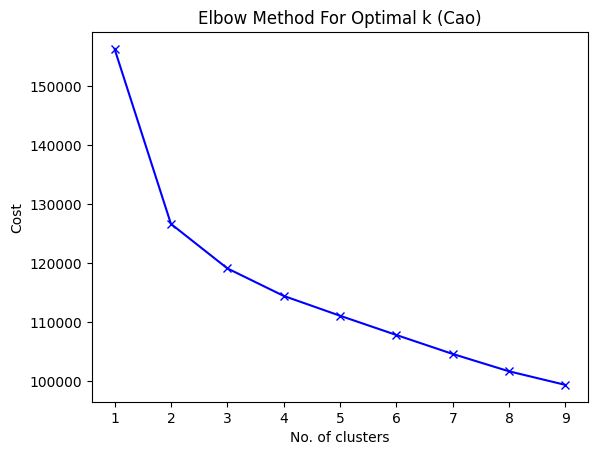

In [22]:
# Elbow curve to find optimal K (Cao)
cost_cao = []
K = range(1,10)

for num_clusters in list(K):
    kmode_cao = KModes(n_clusters=num_clusters, init = "Cao", n_init = 5, verbose=1)
    kmode_cao.fit_predict(global_feature)
    cost_cao.append(kmode_cao.cost_)

plt.plot(K, cost_cao, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k (Cao)')
plt.show()

**Conclusion:**

Based on the elbow point, the optimal choice is K = 3.

# 2. Select K-Mode initialization method & K Value
# 3. Conduct Clustering (Cao, K = 3)

In [33]:
km_cao = KModes(n_clusters=3, init = "Cao", n_init = 1, verbose=1)
global_fitcluster_cao = km_cao.fit_predict(global_feature)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 119105.0


In [34]:
global_fitcluster_cao

array([2, 0, 1, ..., 0, 0, 2], dtype=uint16)

In [35]:
global_cluster_centroids = pd.DataFrame(km_cao.cluster_centroids_)
global_cluster_centroids.columns = global_feature.columns
global_cluster_centroids

,CGPA (categorical),Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Work Study Hours,Financial Stress,Family History,Depression
0,Low,High,Low,Very short,Unhealthy,Yes,High,Moderate,No,1
1,High,Low,High,Adequate,Moderate,No,Moderate,Low,Yes,0
2,Average,Moderate,High,Long,Healthy,Yes,Low,High,Yes,1


From the results above, we can identify 3 major clusters of students:
\
\
Cluster 0: **High-Risk Stressed Achievers**\
Students experiencing severe mental health challenges with low academic performance, high academic pressure, and very short sleep duration. They exhibit unhealthy dietary habits, high work-study hours, and report suicidal thoughts with depression, despite having no family history of mental health issues.
\
\
Cluster 1: **Mentally Healthy High Performers**\
High-achieving students with excellent mental wellness characterized by high CGPA, low academic pressure, and high study satisfaction. They maintain adequate sleep, moderate dietary habits, no suicidal ideation, and low financial stress, though they have a family history of mental health issues but remain depression-free.
\
\
Cluster 2: **Moderate Performers with Financial Stress**\
Students with average academic performance who maintain healthy lifestyle habits (long sleep, healthy diet, low work hours) and high study satisfaction, but struggle with high financial stress and depression. Despite their positive lifestyle choices, they experience suicidal thoughts and have a family history of mental health issues.



In [42]:
# Turn clustering results (global_fitcluster_cao) into dataframe
global_fitcluster_cao_df = pd.DataFrame(global_fitcluster_cao)
global_fitcluster_cao_df.columns = ['Cluster']


# Append predicted clustering results to global_feature's copy, global_feature_clustered
global_feature_clustered =  global_feature.copy()
global_feature_clustered['Cluster'] = global_fitcluster_cao_df
global_feature_clustered

,CGPA (categorical),Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Work Study Hours,Financial Stress,Family History,Depression,Cluster
0,Low,Moderate,High,Long,Healthy,Yes,Moderate,High,Yes,1,2
1,Low,High,High,Very short,Moderate,Yes,Low,Low,No,0,0
2,Low,Low,Moderate,Short,Moderate,No,Moderate,Moderate,No,0,1
3,Low,Low,High,Long,Healthy,No,Low,Moderate,No,0,1
4,Low,Low,High,Very short,Moderate,Yes,Low,Low,No,0,1
...,...,...,...,...,...,...,...,...,...,...,...
27857,High,High,High,Very short,Unhealthy,Yes,High,Low,Yes,1,0
27858,High,Moderate,Low,Long,Unhealthy,Yes,High,High,No,1,0
27859,High,High,Moderate,Very short,Moderate,Yes,High,Moderate,Yes,1,0
27860,High,Moderate,Low,Very short,Moderate,Yes,High,High,No,1,0


# 4. Analyzing/Visualizing Clustering Results


**1. Clustering Results - CGPA, Academic Pressure, Study Satisfaction**

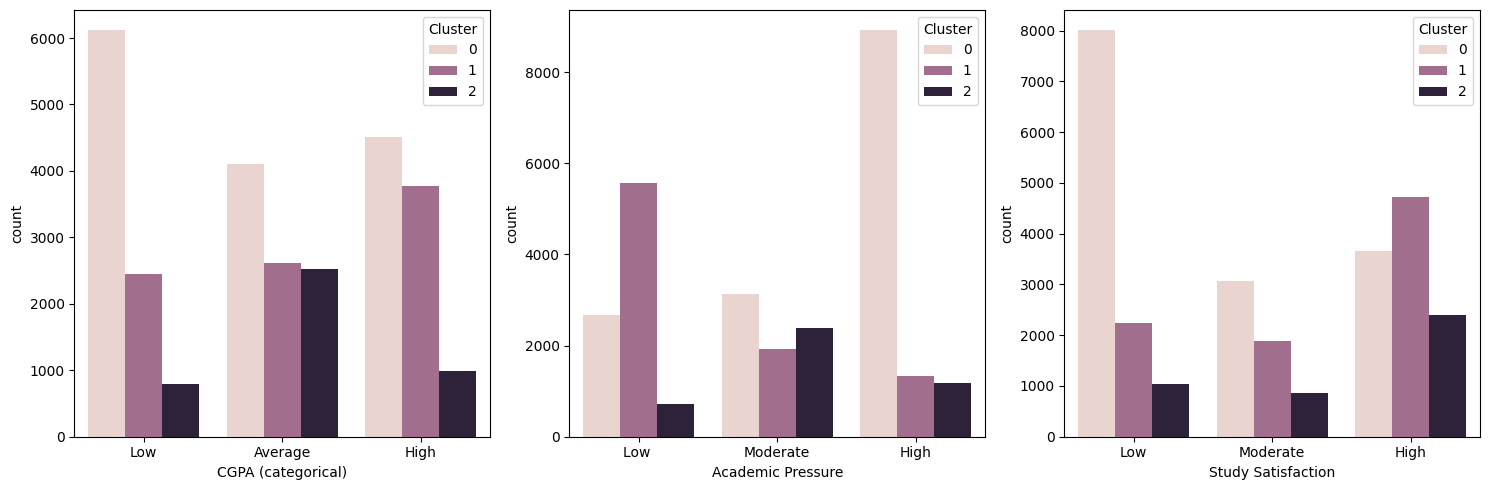

In [46]:
order_cgpa = ['Low', 'Average', 'High']
order_pressure = ['Low ', 'Moderate', 'High']
order_satisfaction = ['Low', 'Moderate', 'High']

f, axs = plt.subplots(1,3,figsize = (15,5))

sns.countplot(x=global_feature_clustered['CGPA (categorical)'],order=order_cgpa,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Academic Pressure'],order=order_pressure,hue=global_feature_clustered['Cluster'],ax=axs[1])
sns.countplot(x=global_feature_clustered['Study Satisfaction'],order=order_satisfaction,hue=global_feature_clustered['Cluster'],ax=axs[2])

plt.tight_layout()
plt.show()


**2. Clustering Results - Sleep, Diet Habits, Work Hours**

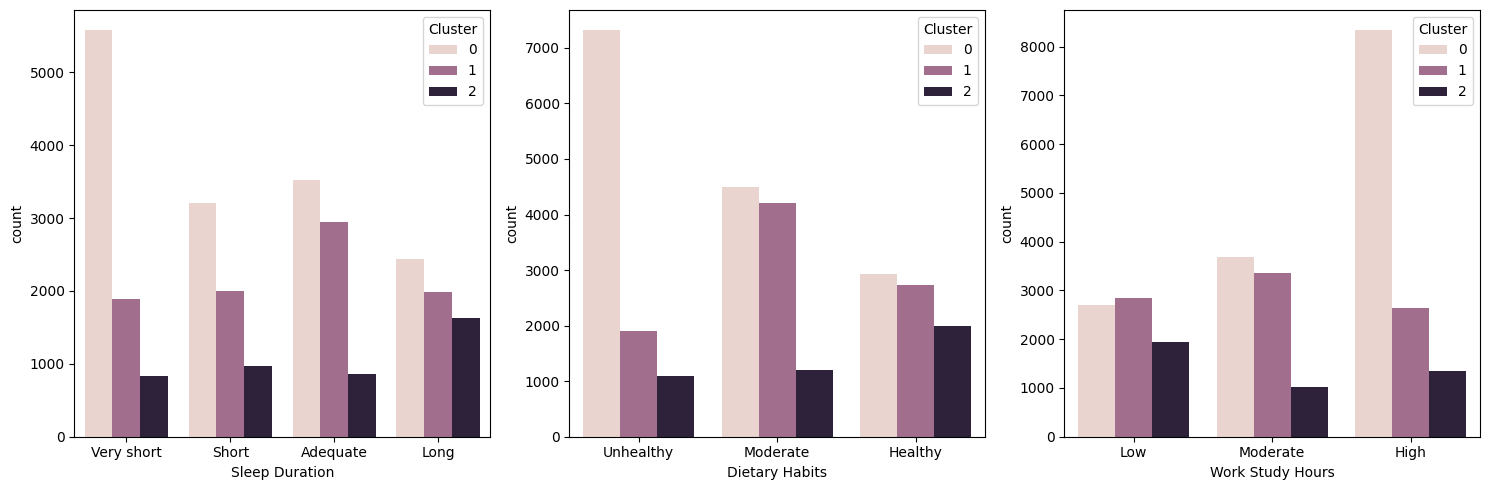

In [48]:
order_sleep = ['Very short', 'Short', 'Adequate', 'Long']
order_diet = ['Unhealthy', 'Moderate', 'Healthy']
order_hours = ['Low', 'Moderate', 'High']


f, axs = plt.subplots(1,3,figsize = (15,5))

sns.countplot(x=global_feature_clustered['Sleep Duration'],order=order_sleep,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Dietary Habits'],order=order_diet,hue=global_feature_clustered['Cluster'],ax=axs[1])
sns.countplot(x=global_feature_clustered['Work Study Hours'],order=order_hours,hue=global_feature_clustered['Cluster'],ax=axs[2])

plt.tight_layout()
plt.show()


**3. Clustering Results - Financial Stress, Family History, Suicidal Thoughts**

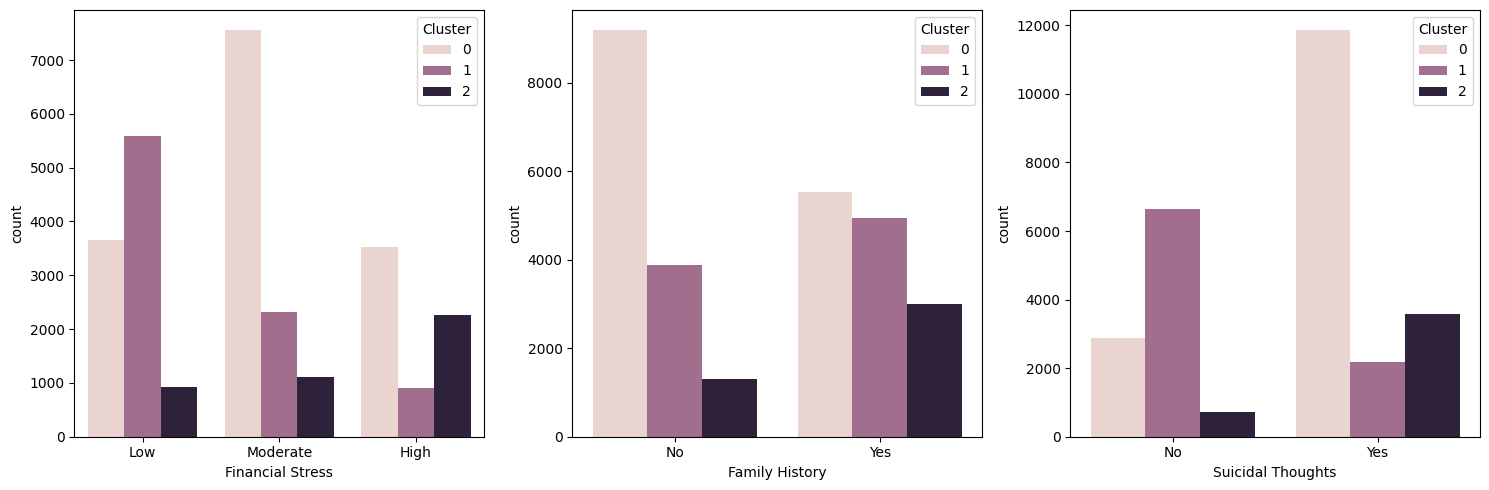

In [50]:
order_finance = ['Low', 'Moderate', 'High']
order_family = ['No', 'Yes']
order_suicidal = ['No', 'Yes']

f, axs = plt.subplots(1,3,figsize = (15,5))

sns.countplot(x=global_feature_clustered['Financial Stress'],order=order_finance,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Family History'],order=order_family,hue=global_feature_clustered['Cluster'],ax=axs[1])
sns.countplot(x=global_feature_clustered['Suicidal Thoughts'],order=order_suicidal,hue=global_feature_clustered['Cluster'],ax=axs[2])


plt.tight_layout()
plt.show()

**4. Clustering Results - Depression (Y/N)**

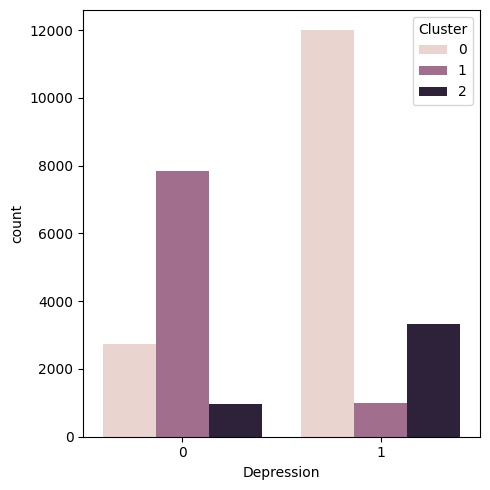

In [53]:
# Convert Depression column to string type so it matches the order parameter
global_feature_clustered['Depression'] = global_feature_clustered['Depression'].astype(str)

order_depression = ['0', '1']

f, axs = plt.subplots(1, 1, figsize=(5, 5))

sns.countplot(
    x=global_feature_clustered['Depression'],
    order=order_depression,
    hue=global_feature_clustered['Cluster'],
    ax=axs
)

plt.tight_layout()